In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/amazon_clean.csv')

# Basic info
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Total Rows: 1465
Total Columns: 16

Column Names:
['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

First 3 rows:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,â¹399,"â¹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,â¹199,â¹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,â¹199,"â¹1,899",90%,3.9,"7,928",ã Fast Charger& Data Syncã-With built-in s...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [3]:
# Data Cleaning
import re

def clean_price(x):
    return float(re.sub(r'[^0-9.]', '', str(x)))

df['actual_price_clean'] = df['actual_price'].apply(clean_price)
df['discounted_price_clean'] = df['discounted_price'].apply(clean_price)
df['discount_pct_clean'] = df['discount_percentage'].str.replace('%', '').astype(float)
df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count_clean'] = df['rating_count'].str.replace(',', '').astype(float)


df['main_category'] = df['category'].str.split('|').str[0]

print("Cleaning done!")
print(df[['actual_price_clean', 'discount_pct_clean', 'rating_clean']].head(3))

Cleaning done!
   actual_price_clean  discount_pct_clean  rating_clean
0              1099.0                64.0           4.2
1               349.0                43.0           4.0
2              1899.0                90.0           3.9


/tmp/ipykernel_5640/2947738229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat.values, y=top_cat.index, palette='viridis')


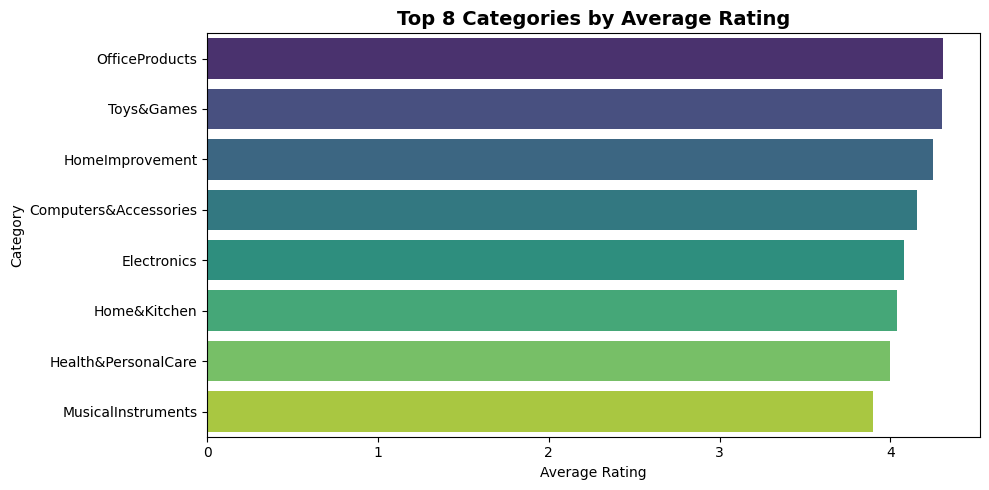

Chart saved!


In [4]:
# Visualization 1: Top 8 Categories by Average Rating
plt.figure(figsize=(10, 5))

top_cat = df.groupby('main_category')['rating_clean'].mean().sort_values(ascending=False).head(8)

sns.barplot(x=top_cat.values, y=top_cat.index, palette='viridis')
plt.title('Top 8 Categories by Average Rating', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()
print("Chart saved!")

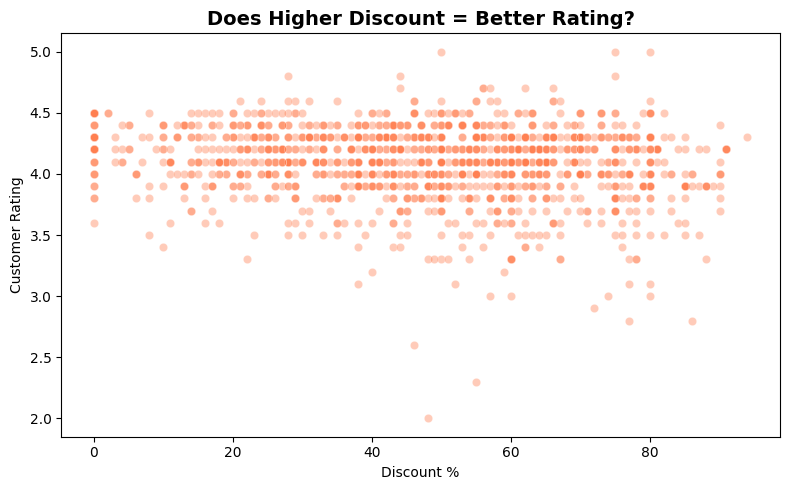

Chart saved!


In [5]:
# Visualization 2: Discount % vs Rating
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='discount_pct_clean', y='rating_clean',
                alpha=0.4, color='coral')

plt.title('Does Higher Discount = Better Rating?', fontsize=14, fontweight='bold')
plt.xlabel('Discount %')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.savefig('discount_vs_rating.png', dpi=150)
plt.show()
print("Chart saved!")

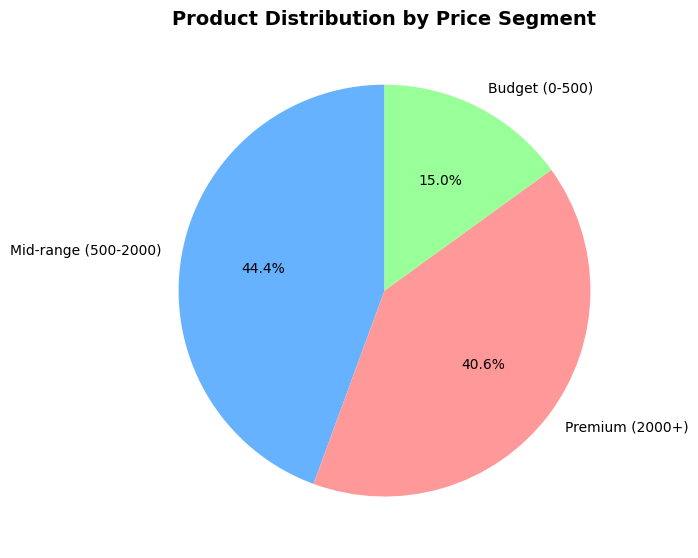

Chart saved!


In [6]:
# Visualization 3: Price Segment Distribution
df['price_segment'] = pd.cut(
    df['actual_price_clean'],
    bins=[0, 500, 2000, 100000],
    labels=['Budget (0-500)', 'Mid-range (500-2000)', 'Premium (2000+)']
)

seg_count = df['price_segment'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#66b2ff', '#ff9999', '#99ff99']
plt.pie(seg_count, labels=seg_count.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Product Distribution by Price Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_segments.png', dpi=150)
plt.show()
print("Chart saved!")